# 02 — Descriptive Statistics

Reads `data/processed/analysis_table.csv` (built in notebook 01) and computes every descriptive statistic from Phase 2 of the roadmap: distributions by phase / status / sponsor type, the enrollment distribution (mean, median, IQR, skewness), registration trends over time, and top conditions studied. This mirrors `src/run_descriptive_stats.py`, which saves the same numbers to `results/descriptive/` for the dashboard.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from src.stats_utils import describe_numeric, frequency_table

df = pd.read_csv('../data/processed/analysis_table.csv',
                  parse_dates=['start_date', 'completion_date'])
df.shape

(9000, 11)

## Distributions: phase, status, sponsor type

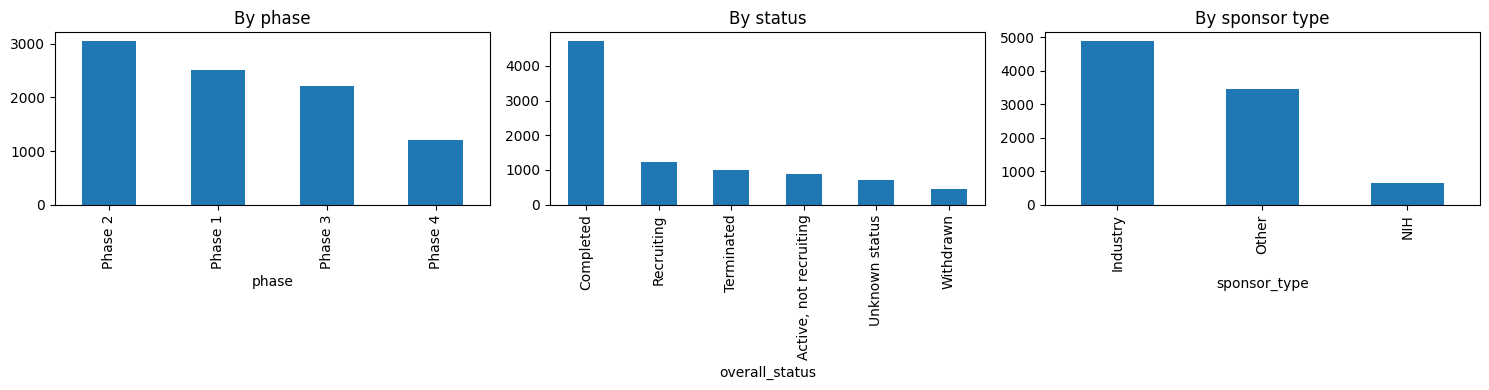

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
frequency_table(df['phase']).set_index('phase')['count'].plot.bar(ax=axes[0], title='By phase')
frequency_table(df['overall_status']).set_index('overall_status')['count'].plot.bar(ax=axes[1], title='By status')
frequency_table(df['sponsor_type']).set_index('sponsor_type')['count'].plot.bar(ax=axes[2], title='By sponsor type')
plt.tight_layout()
plt.show()

## Enrollment size: why report median alongside the mean

Enrollment is expected to be heavily right-skewed — most trials are modest in size, a few are very large multi-site trials. A skewness value greater than roughly 1 is conventionally considered highly skewed; when that holds, the median (and IQR) describes the *typical* trial far better than the mean, which the long tail pulls upward.

         n: 9000
      mean: 152.30
    median: 71.00
       std: 256.75
       iqr: 131.00
        q1: 32.00
        q3: 163.00
  skewness: 5.29
       min: 5.00
       max: 4,095.00


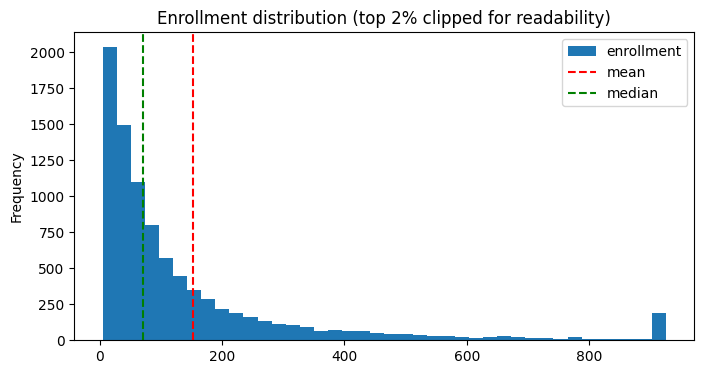

In [3]:
enroll_stats = describe_numeric(df['enrollment'])
for k, v in enroll_stats.items():
    print(f'{k:>10}: {v:,.2f}' if isinstance(v, float) else f'{k:>10}: {v}')

plt.figure(figsize=(8, 4))
df['enrollment'].clip(upper=df['enrollment'].quantile(0.98)).plot.hist(bins=40)
plt.axvline(enroll_stats['mean'], color='red', linestyle='--', label='mean')
plt.axvline(enroll_stats['median'], color='green', linestyle='--', label='median')
plt.legend(); plt.title('Enrollment distribution (top 2% clipped for readability)')
plt.show()

## Trend over time: registrations per year

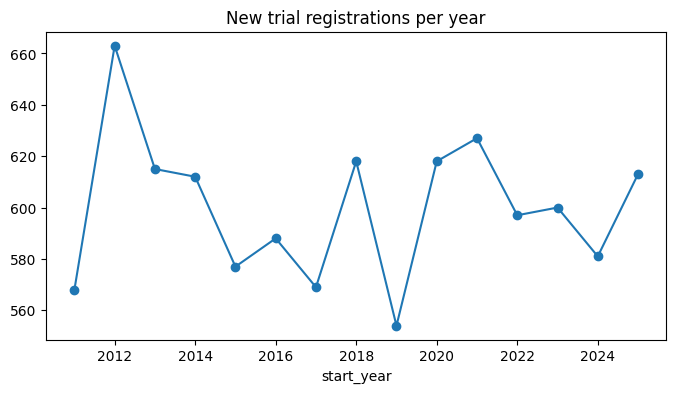

In [4]:
by_year = df.assign(start_year=df['start_date'].dt.year).groupby('start_year').size()
by_year.plot(marker='o', figsize=(8, 4), title='New trial registrations per year')
plt.show()

## Top conditions studied (by primary condition)

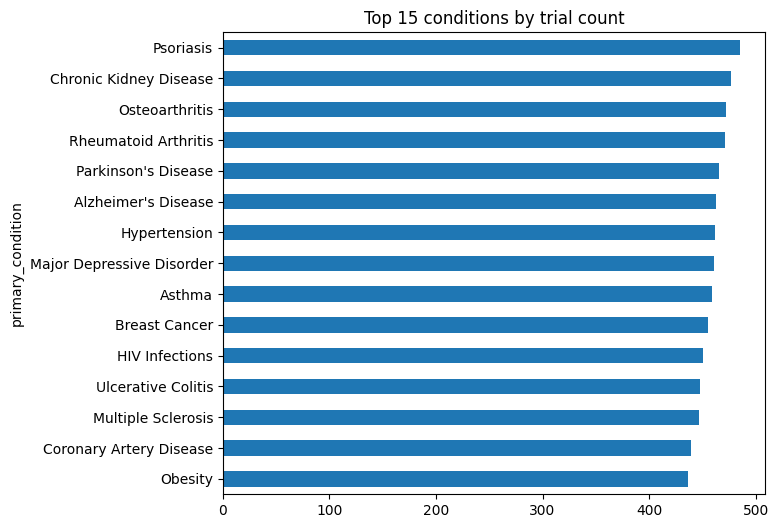

In [5]:
df['primary_condition'].value_counts().head(15).sort_values().plot.barh(figsize=(7, 6))
plt.title('Top 15 conditions by trial count')
plt.show()